In [46]:
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

In [20]:
sns.set(style='ticks', context='talk')

experiment = "shrec_benchmark"

# Folder containing iteration JSON files (iter0.json, iter1.json, etc.)
ITERATIONS_FOLDER = Path("/home/marten/coding/miss-alignment/examples/shrec/iterations")

# Paths to AreTomo JSON files for comparison
ARETOMO2_JSON = Path("/home/marten/coding/miss-alignment/examples/shrec/at2-alignment.json")
ARETOMO3_JSON = Path("/home/marten/coding/miss-alignment/examples/shrec/at3-alignment.json")

Found 7 iteration files: ['iter0.json', 'iter1.json', 'iter2.json', 'iter3.json', 'iter4.json', 'iter5.json', 'iter6.json']
Found 10 models: ['model_0', 'model_1', 'model_2', 'model_3', 'model_4', 'model_5', 'model_6', 'model_7', 'model_8', 'model_9']
Graph for model_0


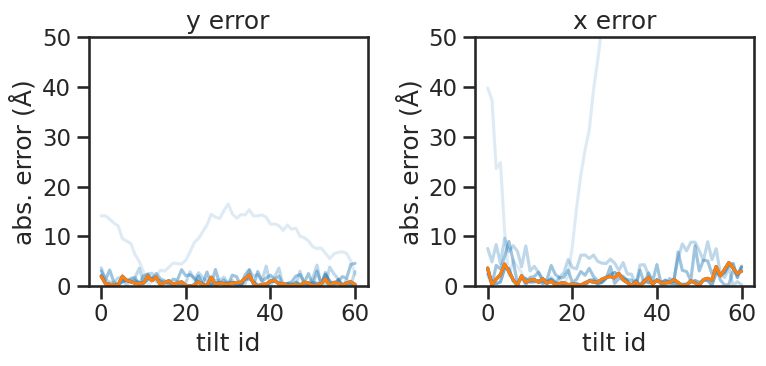

Graph for model_1


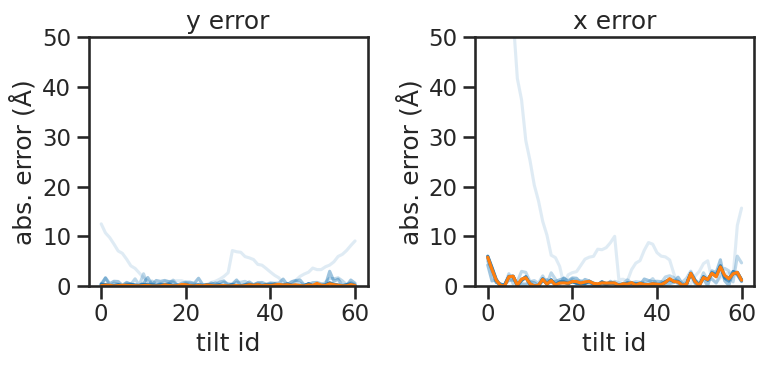

Graph for model_2


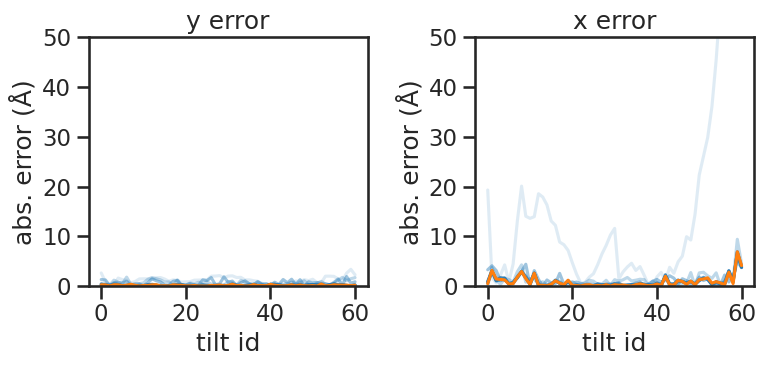

Graph for model_3


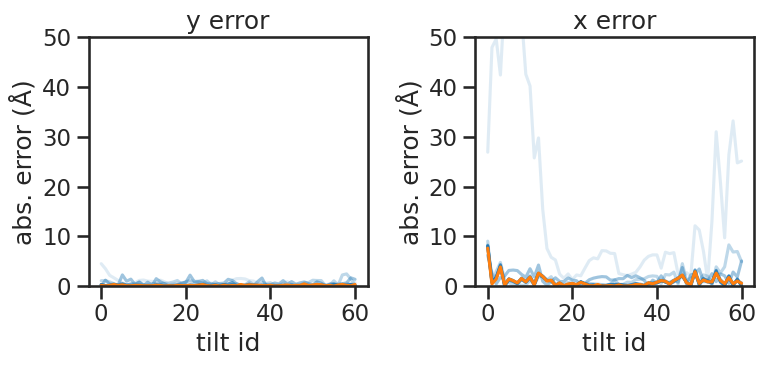

Graph for model_4


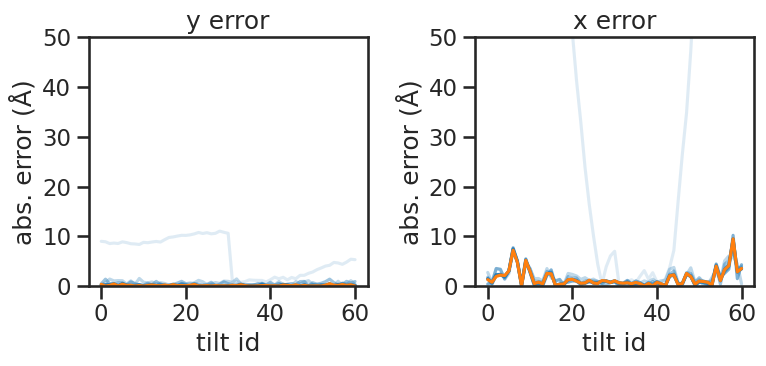

Graph for model_5


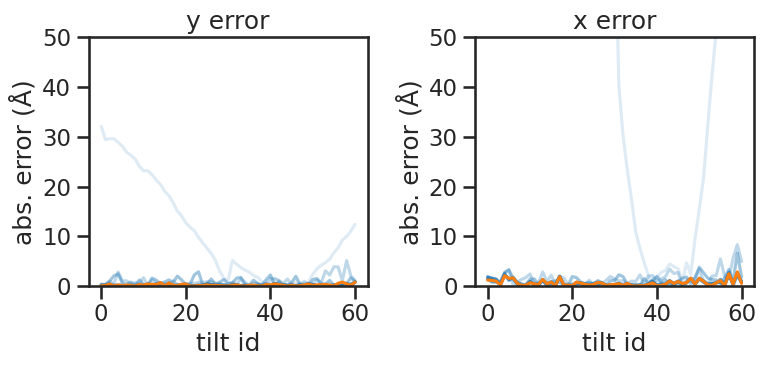

Graph for model_6


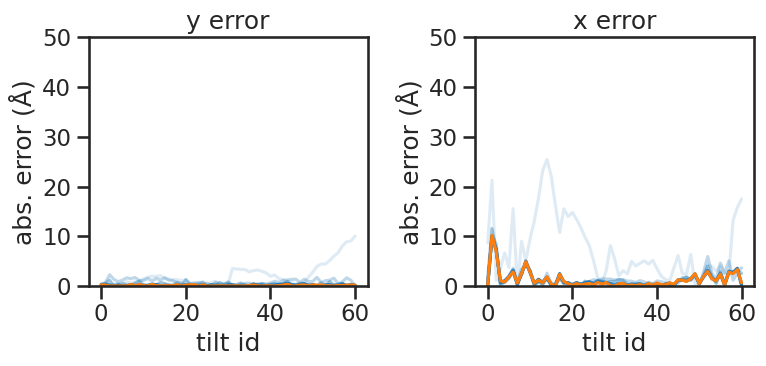

Graph for model_7


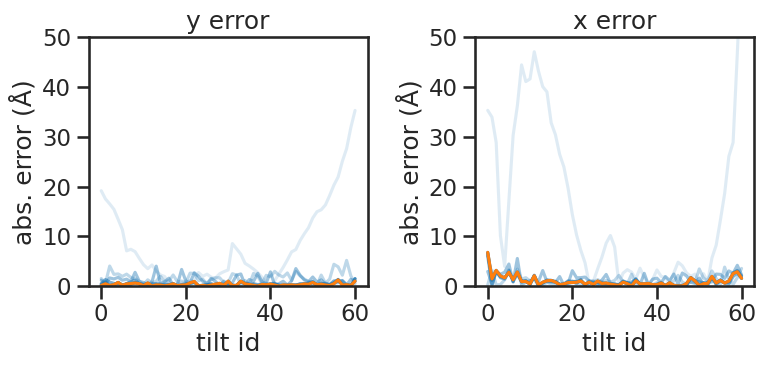

Graph for model_8


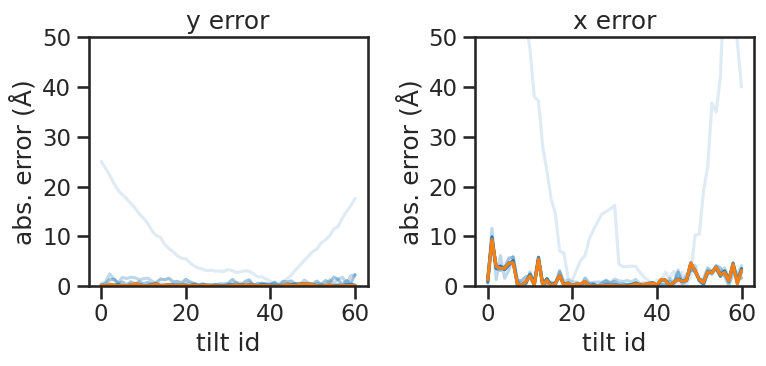

Graph for model_9


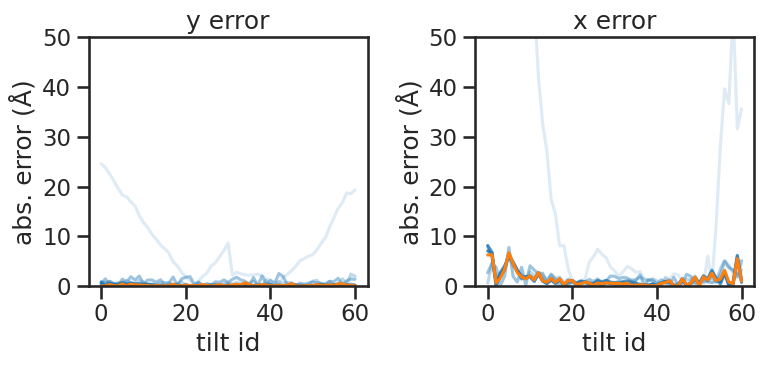

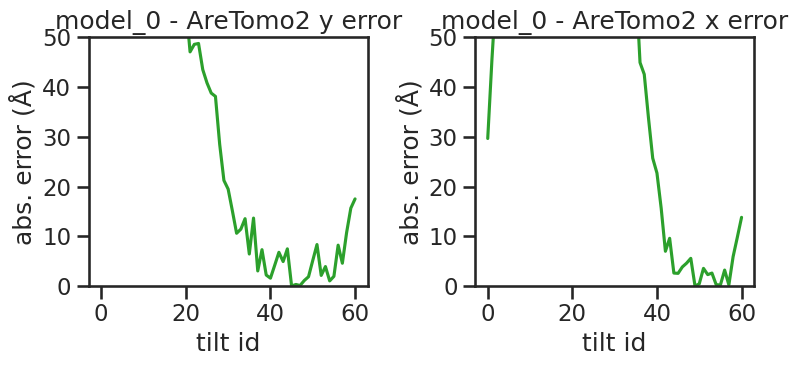

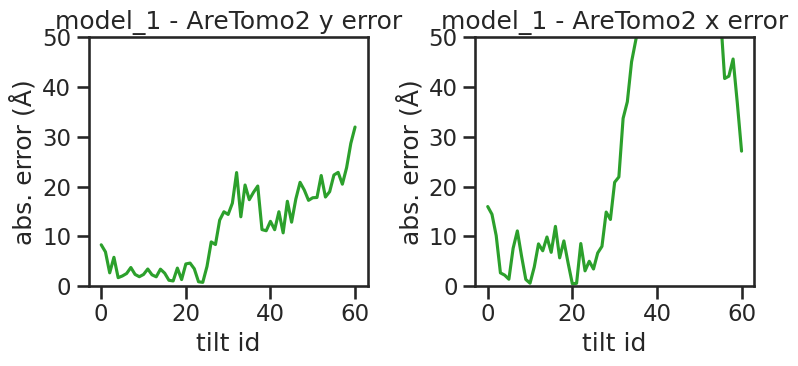

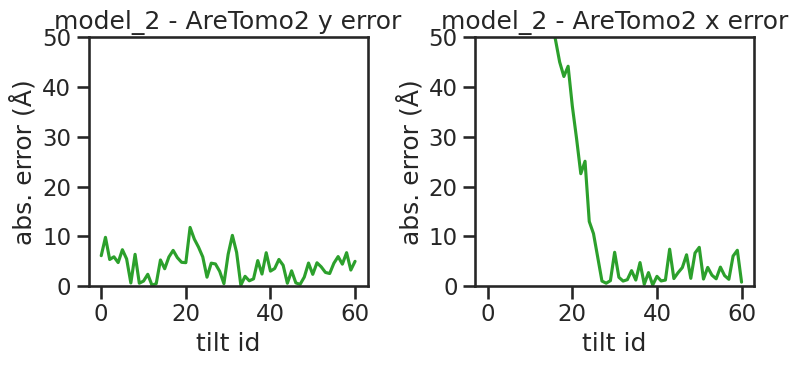

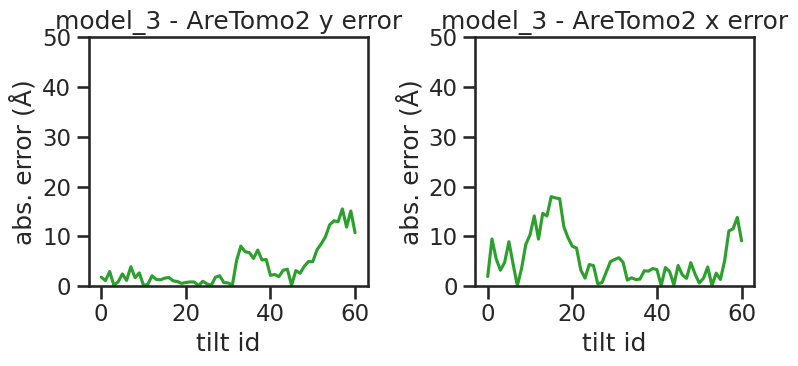

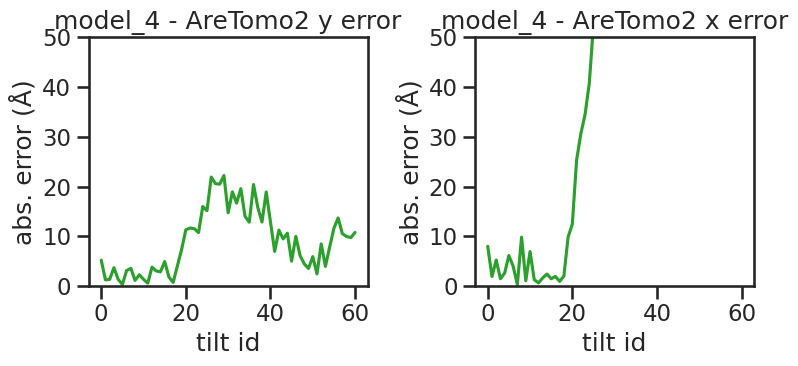

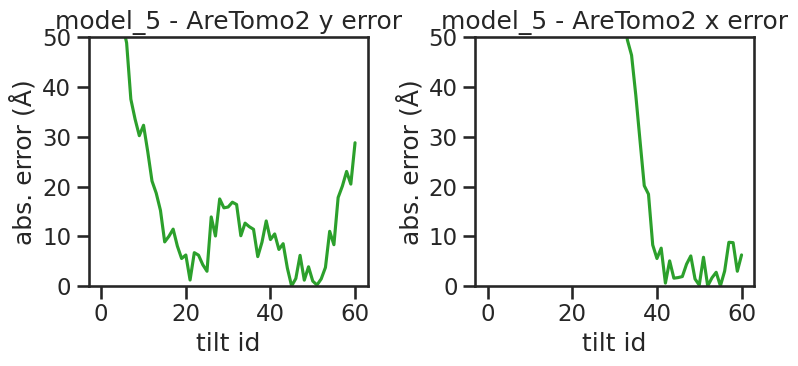

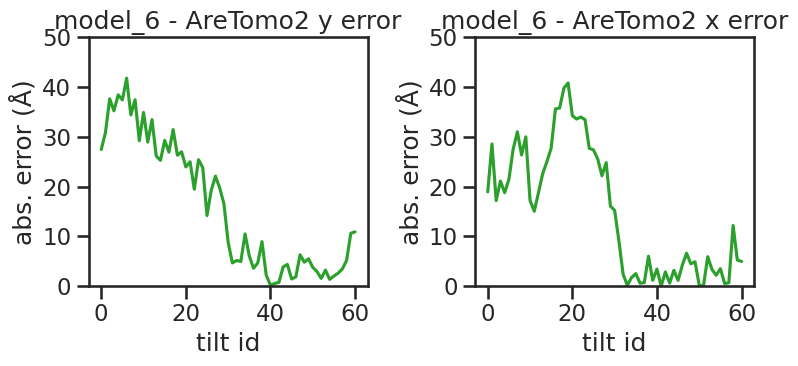

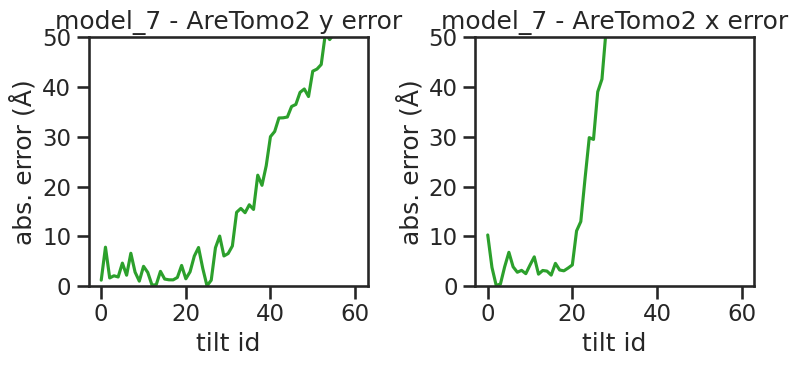

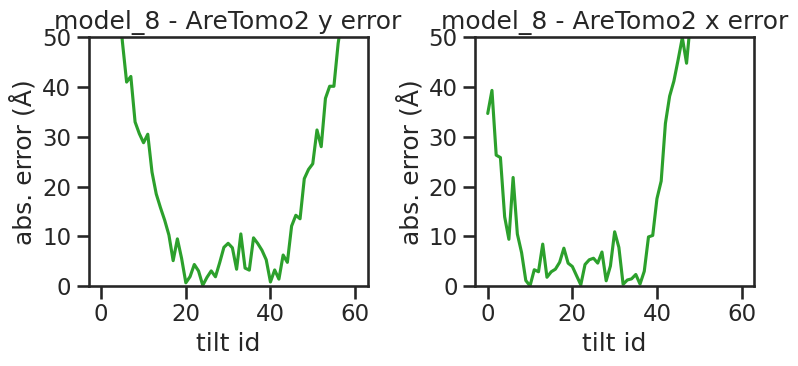

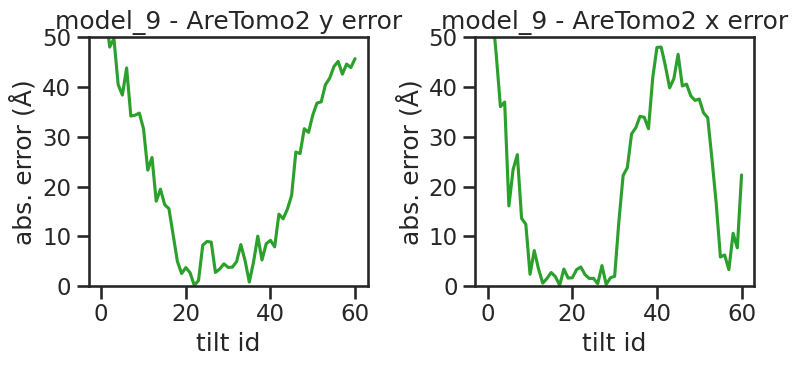

In [21]:
# Find and load all iteration JSON files
iteration_files = sorted(ITERATIONS_FOLDER.glob("iter*.json"), key=lambda x: int(x.stem.replace("iter", "")))
n_iters = len(iteration_files)
print(f"Found {n_iters} iteration files: {[f.name for f in iteration_files]}")

# Load all iteration data
iteration_data = []
for iter_file in iteration_files:
    with open(iter_file) as f:
        iteration_data.append(json.load(f))

# Load AreTomo data for comparison
with open(ARETOMO2_JSON) as f:
    aretomo2_data = json.load(f)

# Get model names from first iteration
model_names = sorted(iteration_data[0].keys())
print(f"Found {len(model_names)} models: {model_names}")

# Collect results for violin plots
results = []

# Plot per-model error curves across iterations
for model_name in model_names:
    print(f'Graph for {model_name}')
    
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    
    for i, iter_data in enumerate(iteration_data):
        if model_name not in iter_data:
            continue
            
        y_errors = torch.tensor(iter_data[model_name]["y_error_angstrom"])
        x_errors = torch.tensor(iter_data[model_name]["x_error_angstrom"])
        
        # Compute combined Euclidean error
        combined_errors = torch.sqrt(y_errors**2 + x_errors**2)
        
        # Store errors for violin plots (absolute for x/y, combined is already positive)
        for y_err, x_err, comb_err in zip(y_errors, x_errors, combined_errors):
            results.append([model_name, f'iter{i}', abs(y_err.item()), abs(x_err.item()), comb_err.item()])
        
        color = 'tab:blue' if i + 1 < n_iters else 'tab:orange'
        ax[0].plot(
            y_errors.abs(), 
            color=color, 
            alpha=(i + 1) / n_iters
        )
        ax[1].plot(
            x_errors.abs(), 
            color=color, 
            alpha=(i + 1) / n_iters
        )
    
    ax[0].set_title('y error')
    ax[0].set_ylabel('abs. error (Å)')
    ax[0].set_xlabel('tilt id')
    ax[0].set_ylim(0, 50)
    ax[1].set_title('x error')
    ax[1].set_ylabel('abs. error (Å)')
    ax[1].set_xlabel('tilt id')
    ax[1].set_ylim(0, 50)
    plt.tight_layout()
    plt.show()


# AreTomo comparison
for model_name in model_names:
    if model_name not in aretomo2_data:
        print(f"Warning: {model_name} not in AreTomo data, skipping")
        continue
        
    y_errors = torch.tensor(aretomo2_data[model_name]["y_error_angstrom"])
    x_errors = torch.tensor(aretomo2_data[model_name]["x_error_angstrom"])
    
    # Compute combined Euclidean error
    combined_errors = torch.sqrt(y_errors**2 + x_errors**2)
    
    # Store errors for violin plots
    for y_err, x_err, comb_err in zip(y_errors, x_errors, combined_errors):
        results.append([model_name, 'aretomo2', abs(y_err.item()), abs(x_err.item()), comb_err.item()])
    
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].plot(y_errors.abs(), color='tab:green', alpha=1.0)
    ax[1].plot(x_errors.abs(), color='tab:green', alpha=1.0)
    ax[0].set_title(f'{model_name} - AreTomo2 y error')
    ax[0].set_ylabel('abs. error (Å)')
    ax[0].set_xlabel('tilt id')
    ax[0].set_ylim(0, 50)
    ax[1].set_title(f'{model_name} - AreTomo2 x error')
    ax[1].set_ylabel('abs. error (Å)')
    ax[1].set_xlabel('tilt id')
    ax[1].set_ylim(0, 50)
    plt.tight_layout()
    plt.show()

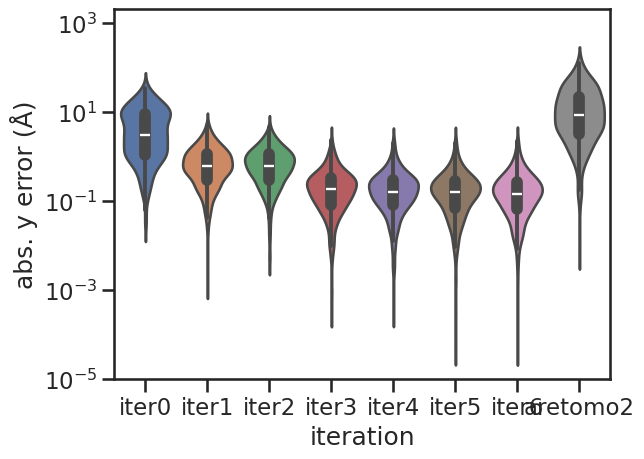

In [24]:
data = pd.DataFrame(results, columns=['model', 'iteration', 'abs_y_error', 'abs_x_error', 'combined_error'])

sns.violinplot(data=data, x='iteration', y='abs_y_error', hue='iteration', legend=False, log_scale=True)
plt.yscale('log')
plt.ylabel('abs. y error (Å)')
plt.ylim(1e-5, 2000)
# plt.savefig(f'{experiment}_violin_abs_y_error.png', dpi=300, bbox_inches='tight')

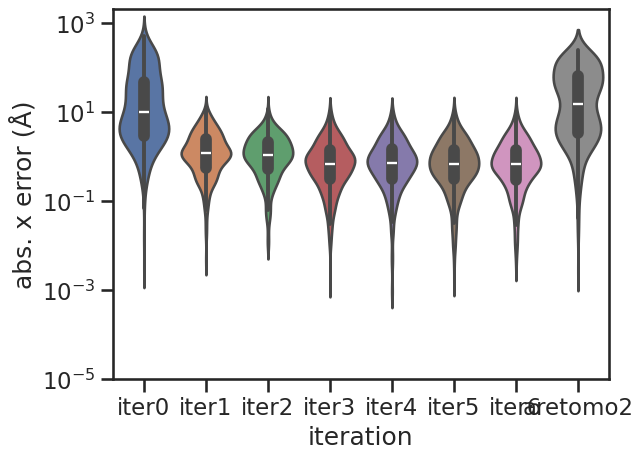

In [25]:
sns.violinplot(data=data, x='iteration', y='abs_x_error', hue='iteration', legend=False, log_scale=True)
plt.yscale('log')
plt.ylabel('abs. x error (Å)')
plt.ylim(1e-5, 2000)
# plt.savefig(f'{experiment}_violin_abs_x_error.png', dpi=300, bbox_inches='tight')

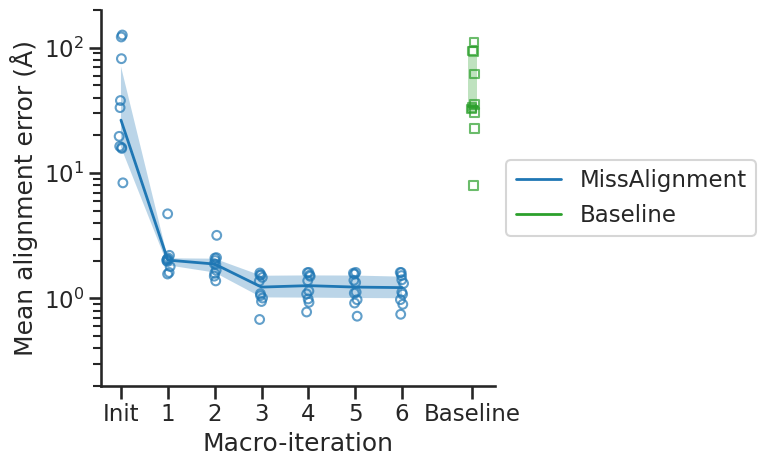

In [94]:
# Compute mean combined error per model per iteration
model_iteration_means = data[data['iteration'].str.startswith('iter')].groupby(
    ['model', 'iteration']
)['combined_error'].mean().reset_index()
model_iteration_means['iter_num'] = model_iteration_means['iteration'].str.replace('iter', '').astype(int)

# Compute median and IQR per iteration (across model means)
iteration_stats = model_iteration_means.groupby('iter_num')['combined_error'].agg(
    median='median',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).reset_index()

# Compute per-model means for AreTomo
aretomo_model_means = data[data['iteration'] == 'aretomo2'].groupby('model')['combined_error'].mean()
aretomo_median = aretomo_model_means.median()
aretomo_q1 = aretomo_model_means.quantile(0.25)
aretomo_q3 = aretomo_model_means.quantile(0.75)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

x = iteration_stats['iter_num'].values
aretomo_x = x[-1] + 1.5

# Plot individual model points (behind, with jitter for visibility)
jitter_strength = 0.1
for model_name in model_names:
    model_data = model_iteration_means[model_iteration_means['model'] == model_name].sort_values('iter_num')
    jitter = (np.random.rand(len(model_data)) - 0.5) * jitter_strength
    ax.scatter(model_data['iter_num'] + jitter, model_data['combined_error'], 
               edgecolor='tab:blue', alpha=0.7, s=40, zorder=1, facecolor='none')
    
    # Plot AreTomo point for this model (squares)
    if model_name in aretomo_model_means.index:
        jitter_at = (np.random.rand() - 0.5) * jitter_strength
        ax.scatter(aretomo_x + jitter_at, aretomo_model_means[model_name], 
                   color='tab:green', alpha=0.7, s=40, marker='s', zorder=1, facecolor='none')

# Plot IQR band (gray, no edges)
ax.fill_between(x, iteration_stats['q1'], iteration_stats['q3'], 
                color='tab:blue', alpha=0.3, edgecolor='none', zorder=2)

# Plot median line (no markers)
ax.plot(x, iteration_stats['median'], '-', color='tab:blue', 
        linewidth=2, label='MissAlignment', zorder=3)

# Plot AreTomo as a short horizontal line with IQR band (similar style to our method)
baseline_half_width = 0.1
baseline_x = [aretomo_x - baseline_half_width, aretomo_x + baseline_half_width]
ax.fill_between(baseline_x, [aretomo_q1, aretomo_q1], [aretomo_q3, aretomo_q3],
                color='tab:green', alpha=0.3, edgecolor='none', zorder=2)
ax.plot(baseline_x, [aretomo_median, aretomo_median], '-', color='tab:green',
        linewidth=2, label='Baseline', zorder=3)

# Formatting
ax.set_xlabel('Macro-iteration')
ax.set_ylabel('Mean alignment error (Å)')
ax.set_xticks(list(x) + [aretomo_x])
ax.set_xticklabels(['Init'] + [f'{i}' for i in x[1:]] + ['Baseline'])
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.yscale('log')
plt.ylim(.2, 200)
sns.despine()

plt.tight_layout()
plt.savefig(f'{experiment}_progression_combined_error.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

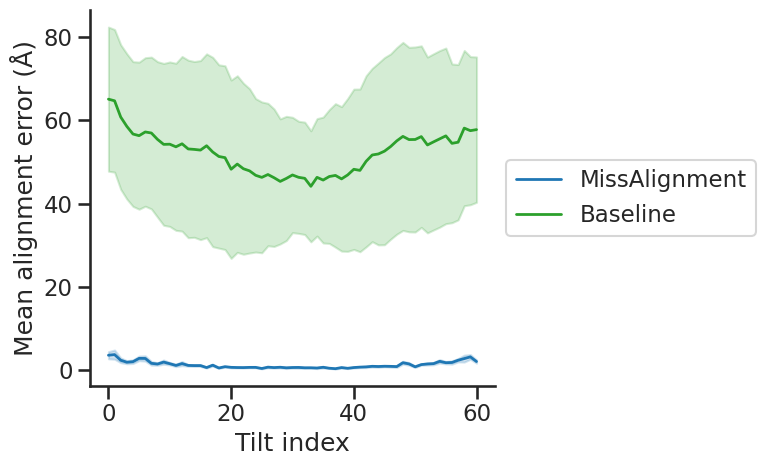

In [93]:
# Per-tilt mean error plot (similar to plot_alignment_comparison.py)
def compute_stats_per_tilt(data_dict):
    """Compute mean and SEM per tilt across all models."""
    all_magnitudes = []
    for model_name, errors in data_dict.items():
        x_errors = np.array(errors["x_error_angstrom"])
        y_errors = np.array(errors["y_error_angstrom"])
        magnitudes = np.sqrt(x_errors**2 + y_errors**2)
        all_magnitudes.append(magnitudes)
    
    all_magnitudes = np.stack(all_magnitudes, axis=0)
    n_models = all_magnitudes.shape[0]
    avg = np.mean(all_magnitudes, axis=0)
    sem = np.std(all_magnitudes, axis=0) / np.sqrt(n_models)
    return avg, avg - sem, avg + sem

# Compute stats for final iteration and baseline
final_avg, final_lo, final_hi = compute_stats_per_tilt(iteration_data[-1])
baseline_avg, baseline_lo, baseline_hi = compute_stats_per_tilt(aretomo2_data)

n_tilts = len(final_avg)
tilt_indices = np.arange(n_tilts)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot SEM bands
ax.fill_between(tilt_indices, final_lo, final_hi, alpha=0.2, color='tab:blue')
ax.fill_between(tilt_indices, baseline_lo, baseline_hi, alpha=0.2, color='tab:green')

# Plot mean curves
ax.plot(tilt_indices, final_avg, label='MissAlignment', linewidth=2, color='tab:blue')
ax.plot(tilt_indices, baseline_avg, label='Baseline', linewidth=2, color='tab:green')

ax.set_xlabel('Tilt index')
ax.set_ylabel('Mean alignment error (Å)')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

plt.tight_layout()
plt.savefig(f'{experiment}_per_tilt_error.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()